# 01 - EDA Exploratorio: Tweets sobre precios de alimentos en Lima

Análisis exploratorio de los tweets recolectados con `twscrape` (2015-2024) para el proyecto de Big Data. Cubre: estructura de los datos, calidad (duplicados, nulos, outliers), distribución temporal, términos de búsqueda, distritos, engagement (likes/retweets), y palabras más frecuentes.

**Antes de correr:** ejecuta la celda de abajo y sube tu archivo `bronce_tweets_precios_lima.json` cuando te lo pida.

In [1]:
from google.colab import files

print("Sube tu archivo bronce_tweets_precios_lima.json:")
subido = files.upload()
RUTA_JSON = list(subido.keys())[0]
print(f"\nArchivo cargado: {RUTA_JSON}")

Sube tu archivo bronce_tweets_precios_lima.json:


Saving bronce_tweets_precios_lima.json to bronce_tweets_precios_lima (1).json

Archivo cargado: bronce_tweets_precios_lima (1).json


In [2]:
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Carga y estructura de los datos

In [3]:
with open(RUTA_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df["fecha"] = pd.to_datetime(df["fecha"])

print(f"Total de registros: {len(df):,}")
print(f"Columnas: {list(df.columns)}")
df.head()

Total de registros: 5,133
Columnas: ['id', 'fecha', 'comentario', 'likes', 'retweets', 'termino_busqueda', 'distrito']


,id,fecha,comentario,likes,retweets,termino_busqueda,distrito
0,654512717814960128,2015-10-15 04:22:46+00:00,SUBE PRECIO DE PAPA a S/.2 y 4 EN MERCADO DE L...,1,0,precio papa Lima,NaN
1,783361353436332033,2016-10-04 17:41:15+00:00,"Precio de papa se dispara en Lima, es el resul...",5,15,precio papa Lima,NaN
2,731304797631053825,2016-05-14 02:07:05+00:00,"Precio mayorista de papa, pollo, manzana y uva...",11,11,precio papa Lima,NaN
3,730588341507219456,2016-05-12 02:40:08+00:00,"Precio mayorista de papa, pollo, manzana y uva...",12,6,precio papa Lima,NaN
4,730529181977722883,2016-05-11 22:45:04+00:00,"Precio mayorista de papa, pollo, manzana y uva...",0,0,precio papa Lima,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5133 entries, 0 to 5132
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                5133 non-null   int64              
 1   fecha             5133 non-null   datetime64[ns, UTC]
 2   comentario        5133 non-null   object             
 3   likes             5133 non-null   int64              
 4   retweets          5133 non-null   int64              
 5   termino_busqueda  5133 non-null   object             
 6   distrito          4934 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(3), object(3)
memory usage: 280.8+ KB


## 2. Calidad de datos: duplicados y nulos

In [5]:
print("Duplicados por id:", df.duplicated(subset="id").sum())
print("Duplicados por texto de comentario:", df.duplicated(subset="comentario").sum())
print("\nValores nulos por columna:")
print(df.isnull().sum())

if "distrito" in df.columns:
    pct_sin_distrito = df["distrito"].isnull().mean() * 100
    print(f"\n% de tweets sin distrito detectado (ni siquiera 'Lima' genérico): {pct_sin_distrito:.1f}%")

Duplicados por id: 0
Duplicados por texto de comentario: 159

Valores nulos por columna:
id                    0
fecha                 0
comentario            0
likes                 0
retweets              0
termino_busqueda      0
distrito            199
dtype: int64

% de tweets sin distrito detectado (ni siquiera 'Lima' genérico): 3.9%


In [6]:
# Quitamos duplicados por texto de comentario para el resto del análisis
n_antes = len(df)
df = df.drop_duplicates(subset="comentario").reset_index(drop=True)
print(f"Registros: {n_antes} -> {len(df)} (se quitaron {n_antes - len(df)} duplicados)")

Registros: 5133 -> 4974 (se quitaron 159 duplicados)


## 3. Distribución temporal

Punto clave para el proyecto: la cobertura de X para tweets antiguos (2015-2018) es baja. Aquí se cuantifica cuánto.

Rango de fechas: 2015-01-10 a 2024-06-26

Tweets por año:
fecha
2015     164
2016     169
2017     252
2018     345
2019     361
2020     557
2021     886
2022    1111
2023     776
2024     353
Name: count, dtype: int64


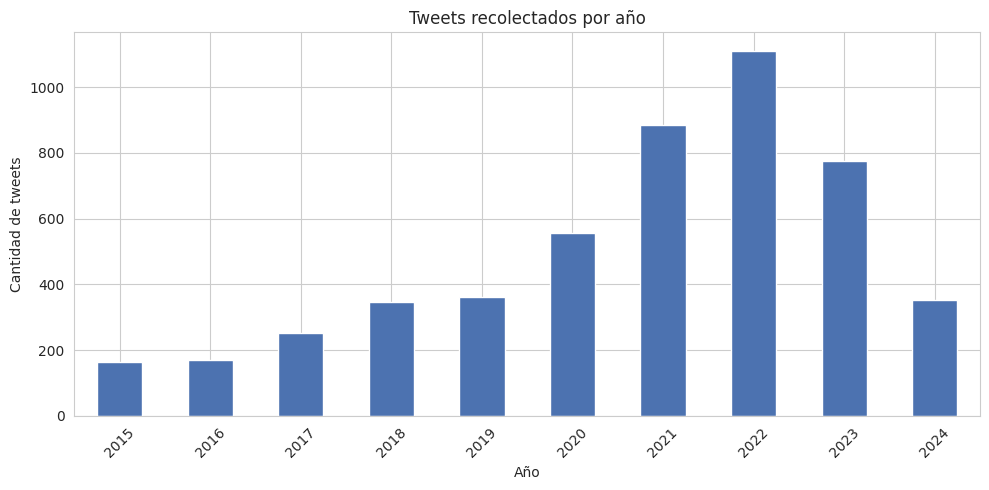

In [7]:
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")

por_anio = df["fecha"].dt.year.value_counts().sort_index()
print("\nTweets por año:")
print(por_anio)

fig, ax = plt.subplots()
por_anio.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Tweets recolectados por año")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

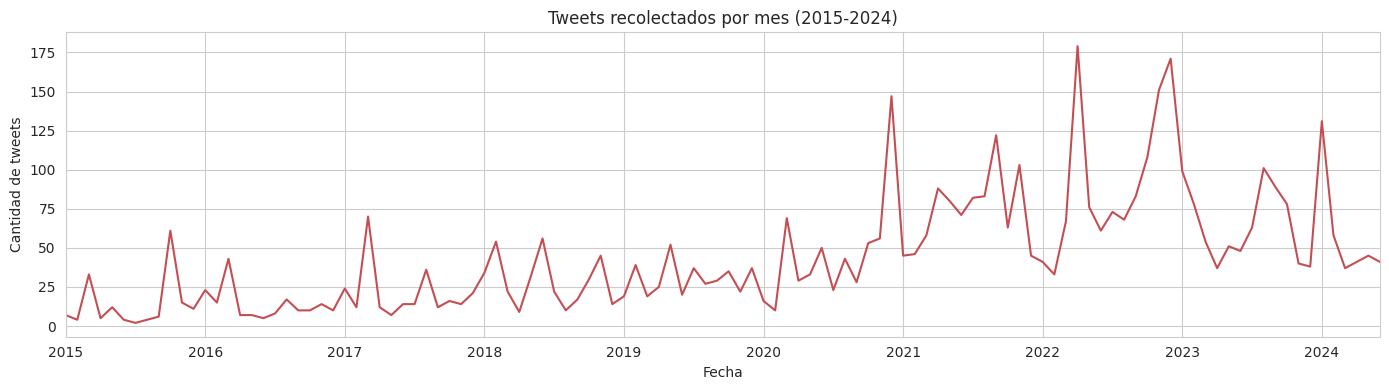

Top 5 meses con más tweets (posibles picos de alza de precios):
fecha
2022-04-30 00:00:00+00:00    179
2022-12-31 00:00:00+00:00    171
2022-11-30 00:00:00+00:00    151
2020-12-31 00:00:00+00:00    147
2024-01-31 00:00:00+00:00    131
dtype: int64


In [8]:
# Vista mensual para ver estacionalidad / picos puntuales (ej. eventos de alza de precios)
por_mes = df.set_index("fecha").resample("ME").size()

fig, ax = plt.subplots(figsize=(14, 4))
por_mes.plot(ax=ax, color="#C44E52")
ax.set_title("Tweets recolectados por mes (2015-2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de tweets")
plt.tight_layout()
plt.show()

print("Top 5 meses con más tweets (posibles picos de alza de precios):")
print(por_mes.sort_values(ascending=False).head())

## 4. Términos de búsqueda

Términos de búsqueda únicos usados: 132

Top 20 términos que más tweets aportaron:
termino_busqueda
mercado mayorista Lima         437
desabastecimiento Lima         423
paro de transportistas Lima    325
precio pollo Lima              261
por las nubes Lima             215
paro agrario Lima              183
bloqueo de carreteras Lima     178
alza de precios Lima           170
precio limón Lima              168
canasta básica Lima            150
inflación en Perú Lima         117
precio peaje Lima              107
ya no alcanza Lima             105
crisis económica Perú Lima      94
precio bonito Lima              93
aumento de precios Lima         92
precio gasolina Lima            91
Metro precios Lima              88
inflación alimentos Lima        80
precio papa Lima                79
Name: count, dtype: int64


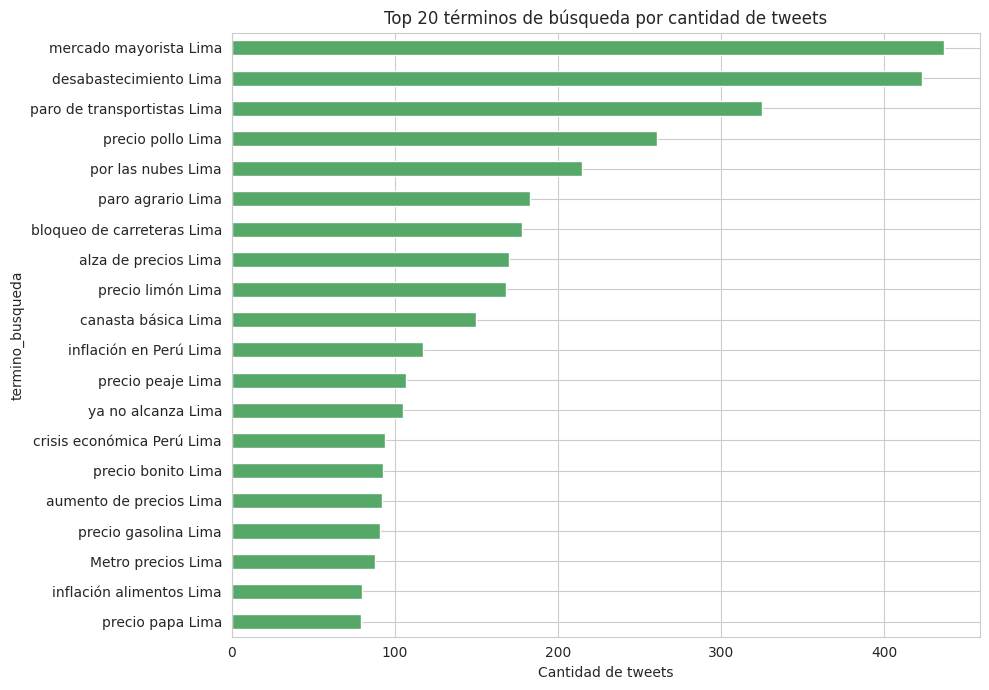

In [9]:
print(f"Términos de búsqueda únicos usados: {df['termino_busqueda'].nunique()}")

top_terminos = df["termino_busqueda"].value_counts().head(20)
print("\nTop 20 términos que más tweets aportaron:")
print(top_terminos)

fig, ax = plt.subplots(figsize=(10, 7))
top_terminos.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Top 20 términos de búsqueda por cantidad de tweets")
ax.set_xlabel("Cantidad de tweets")
plt.tight_layout()
plt.show()

## 5. Distribución por distrito

**Advertencia de calidad de datos encontrada en este análisis:** la detección de distrito busca el nombre como substring dentro del texto, sin respetar límites de palabra. Esto genera falsos positivos notorios, el más claro es **"Ate"**, que aparece dentro de palabras como "tom**ATE**" o "**ATE**NCIÓN". Se documenta abajo con evidencia y se recomienda corregir con `\b` (límites de palabra) en regex para la siguiente iteración del pipeline de recolección.

distrito
Lima (sin distrito específico)    3763
Ate                                381
Callao                             309
Independencia                       70
Santa Anita                         43
Santa Rosa                          40
La Victoria                         22
Miraflores                          14
Rímac                               11
Jesús María                          8
Chorrillos                           8
Puente Piedra                        8
Lurigancho                           7
Los Olivos                           6
Pachacámac                           6
Barranco                             6
La Molina                            5
Carabayllo                           5
Breña                                5
Lurín                                5
San Luis                             5
La Perla                             4
Villa El Salvador                    4
San Borja                            4
Chaclacayo                           4
Lince           

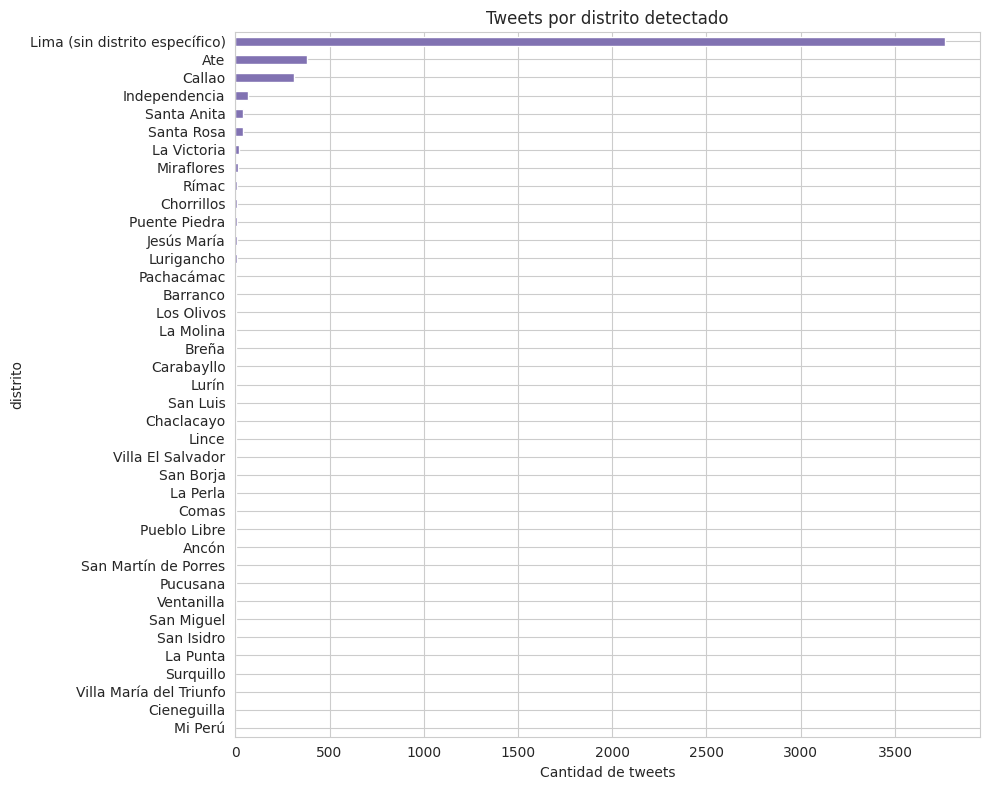

In [10]:
if "distrito" in df.columns:
    dist_counts = df["distrito"].value_counts()
    print(dist_counts)

    fig, ax = plt.subplots(figsize=(10, 8))
    dist_counts.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
    ax.set_title("Tweets por distrito detectado")
    ax.set_xlabel("Cantidad de tweets")
    plt.tight_layout()
    plt.show()
else:
    print("Esta corrida no tiene columna 'distrito'.")

In [11]:
# Evidencia del falso positivo de "Ate"
if "distrito" in df.columns and "Ate" in df["distrito"].values:
    muestra_ate = df[df["distrito"] == "Ate"]["comentario"].head(5)
    print("Muestra de tweets clasificados como distrito='Ate' (revisar si mencionan Ate de verdad):\n")
    for c in muestra_ate:
        print("-", c[:140])
        print()

Muestra de tweets clasificados como distrito='Ate' (revisar si mencionan Ate de verdad):

- En oriente no se calientan los chicharrones en el microondas... Se cocinan con tomate, cebolla y chile. 
Este sábado traeremos chicharrones 

- Ingreso de alimentos a Lima se regulariza, pero precio de tomate y alverja siguen al alza https://t.co/SSEIsTLDWW

- Aquí la disminución en el precio de diversos productos a lo largo de mayo que tuvieron mayor impacto en el índice de precios al consumidor e

- ¡ATENCIÓN! Precio del pollo sube 50% en mercados de Lima https://t.co/aC692F4Qkt https://t.co/q3NpvYzaEk

- ¡ATENCIÓN! Precio del pollo sube 50% en mercados de Lima https://t.co/jAtNYrbcJw https://t.co/HHFtSiOXIr



## 6. Longitud de los comentarios

count     4974.000000
mean       267.619019
std        721.891767
min         24.000000
25%        139.000000
50%        228.000000
75%        279.000000
max      23660.000000
Name: longitud, dtype: float64


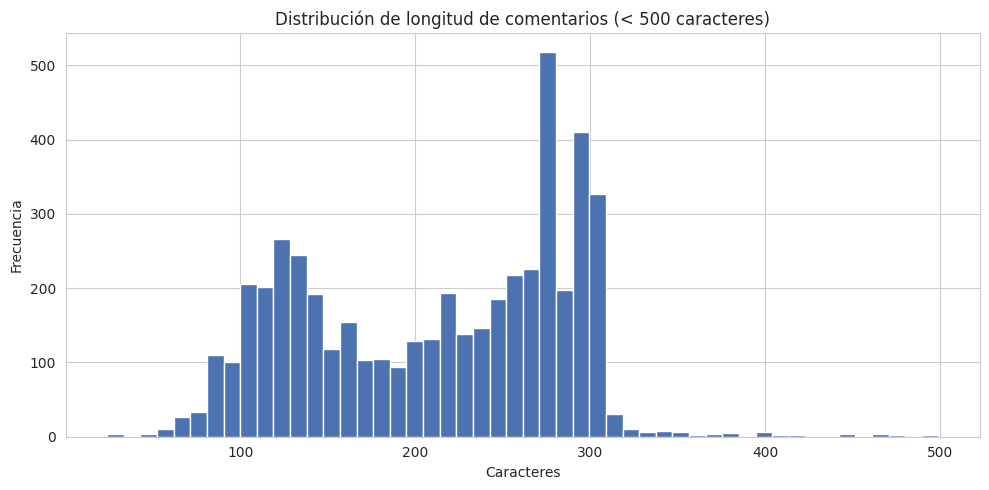


Tweets con más de 500 caracteres (posible ruido / texto no relacionado): 91


In [12]:
df["longitud"] = df["comentario"].str.len()
print(df["longitud"].describe())

fig, ax = plt.subplots()
df[df["longitud"] < 500]["longitud"].hist(bins=50, ax=ax, color="#4C72B0")
ax.set_title("Distribución de longitud de comentarios (< 500 caracteres)")
ax.set_xlabel("Caracteres")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("\nTweets con más de 500 caracteres (posible ruido / texto no relacionado):", (df["longitud"] > 500).sum())

In [13]:
# El comentario más largo -- vale la pena revisar si es ruido (tweet fuera de tema)
idx_max = df["longitud"].idxmax()
print(f"Comentario más largo ({df.loc[idx_max, 'longitud']} caracteres), término: '{df.loc[idx_max, 'termino_busqueda']}'\n")
print(df.loc[idx_max, "comentario"][:600])

Comentario más largo (23660 caracteres), término: 'todo está caro Lima'

Yamandú Orsi: “Hoy estamos acostumbrados al escándalo permanente” - 1° Parte

Al precandidato frenteamplista le preocupa la “falta de transparencia” y la “incertidumbre” que genera el gobierno, y consideró que frente a esto el Frente Amplio representa “una respuesta totalmente esperanzadora”
El intendente de Canelones, Yamandú Orsi, es uno de los cuatro precandidatos del Frente Amplio (FA) que se medirán en el Congreso de diciembre. Dice que sería “un cínico” si firmara por el plebiscito de seguridad social porque no lo acompaña, y adelanta que no se referirá a eso en los discursos, pero no cr


## 7. Engagement: likes y retweets

               likes      retweets
count    4974.000000   4974.000000
mean      104.883997     36.457982
std      3122.269953   1156.640799
min         0.000000      0.000000
25%         2.000000      0.000000
50%         4.000000      1.000000
75%        12.000000      5.000000
max    216779.000000  80708.000000


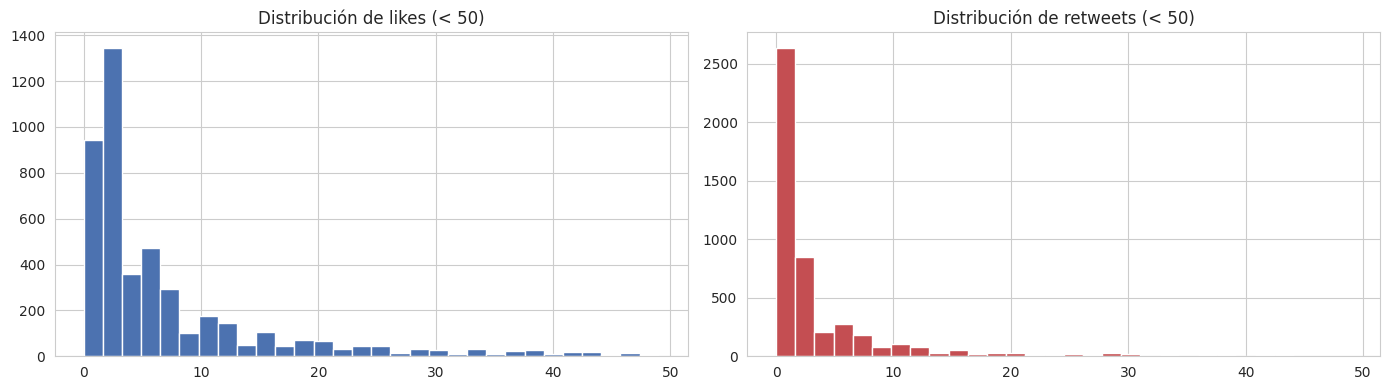


Top 5 tweets con más likes:
[2023-08-10] 216779 likes: Ep. 15  Former Capitol Police Chief Steven Sund reveals what really happened on January 6th. Our Fox News interview with

[2024-01-19] 24136 likes: ¿Quién se llevó el oro de América?
Estoy muy cansado de escuchar a los indigenistas hablar del robo del oro por parte de

[2023-09-26] 17262 likes: The World’s 50 best restaurants 2023:

1. 🇵🇪 Lima: Central
2. 🇪🇸 Barcelona: Disfrutar
3. 🇪🇸 Madrid: DiverXO
4. 🇪🇸 Atxond

[2023-07-01] 12100 likes: 5º año del triunfo histórico democrático del pueblo de México https://t.co/8aqZoi7qJ0

[2024-04-12] 8296 likes: ALERTA 🚨
Un grupo de turistas israelíes agreden a ciudadanos peruanos que realizaban una vigilia en solidaridad con el p



In [15]:
print(df[["likes", "retweets"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df[df["likes"] < 50]["likes"].hist(bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de likes (< 50)")
df[df["retweets"] < 50]["retweets"].hist(bins=30, ax=axes[1], color="#C44E52")
axes[1].set_title("Distribución de retweets (< 50)")
plt.tight_layout()
plt.show()

print("\nTop 5 tweets con más likes:")
for _, row in df.nlargest(5, "likes")[["fecha", "likes", "comentario"]].iterrows():
    print(f"[{row['fecha'].date()}] {row['likes']} likes: {row['comentario'][:120]}")
    print()

## 8. Palabras más frecuentes

Limpieza simple (minúsculas, sin URLs/menciones, sin stopwords en español) solo para exploración -- la limpieza definitiva para el modelo de sentimiento se hace en el notebook de preprocesamiento.

precio               1650
precios              1012
mercado               733
mayorista             634
paro                  614
alimentos             515
gran                  470
desabastecimiento     446
hoy                   420
transportistas        397
#lima                 390
mercados              343
metropolitana         329
alza                  323
pollo                 322
productos             320
callao                314
inflación             300
canasta               276
tiene                 257
básica                255
limón                 245
año                   241
solo                  240
país                  234
dtype: int64


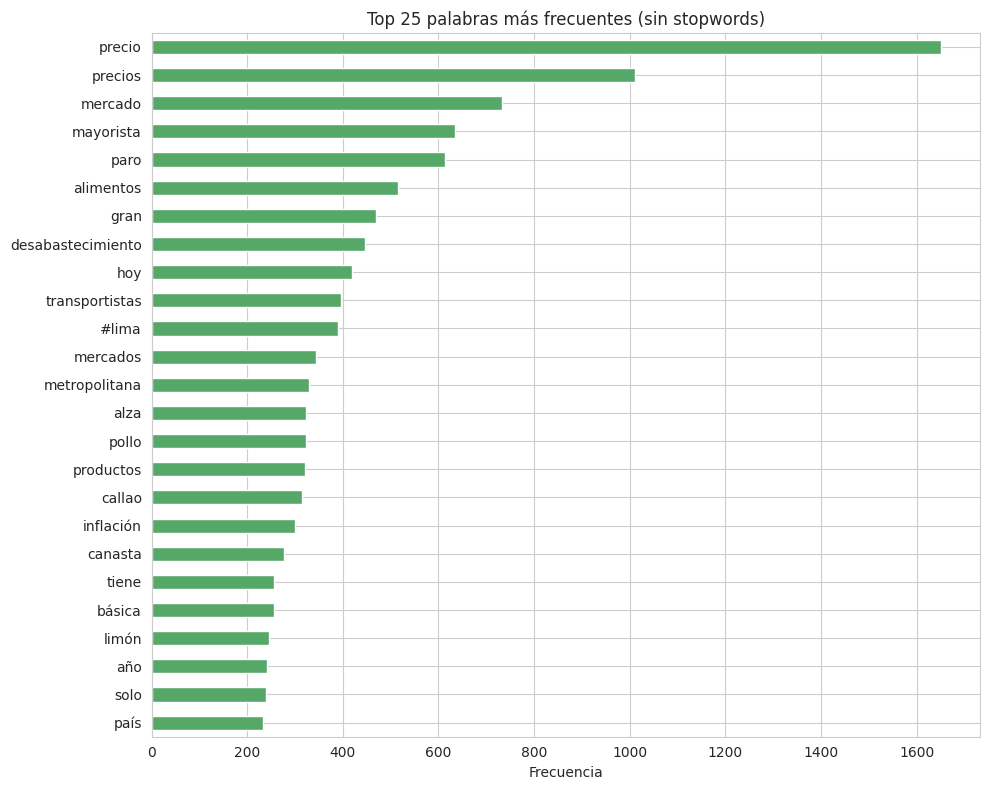

In [16]:
STOPWORDS_ES = set("""de la que el en y a los del se las por un para con no una su al lo como más
o pero sus le ya así porque muy sin sobre también me hasta hay donde quien desde todo nos durante
todos uno les ni contra otros ese eso ante ellos esto mi antes algunos qué unos yo otro otras
otra él tanto esa estos mucho quienes nada muchos cual poco ella estar estas algunas algo nosotros
mis tu tus te ti era son fue ser está están soy eres somos sois esas este esta
será han eso rt via lima peru perú""".split())


def limpiar_tokens(texto):
    texto = re.sub(r"http\S+", "", texto.lower())
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"[^a-záéíóúñü#\s]", " ", texto)
    return [t for t in texto.split() if len(t) > 2 and t not in STOPWORDS_ES]


todas_palabras = []
for c in df["comentario"]:
    todas_palabras.extend(limpiar_tokens(c))

conteo = Counter(todas_palabras)
top_palabras = pd.Series(dict(conteo.most_common(25)))

print(top_palabras)

fig, ax = plt.subplots(figsize=(10, 8))
top_palabras.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Top 25 palabras más frecuentes (sin stopwords)")
ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()

## 9. Resumen y hallazgos clave

- **Volumen**: ver total de registros y duplicados eliminados arriba.
- **Cobertura temporal desigual**: 2015-2018 aportan muchos menos tweets que 2020-2023 (limitación conocida de la búsqueda de X para contenido antiguo, ya documentada en el proyecto).
- **Sesgo hacia contenido noticioso**: los términos que más aportan (`mercado mayorista`, `desabastecimiento`, `paro de transportistas`) son en su mayoría de tono noticioso/institucional (medios, gremios) más que quejas individuales de consumidores.
- **Problema de calidad detectado**: la columna `distrito` tiene falsos positivos por coincidencia de substring (caso "Ate"). Recomendado corregir con límites de palabra (`\b`) antes de usar esta columna para análisis geográfico serio.
- **Outliers de longitud**: existen tweets muy largos que parecen no estar relacionados al tema (ruido de la búsqueda por palabras clave genéricas). Vale la pena revisarlos antes del análisis de sentimiento.

**Siguiente paso sugerido**: notebook `02_Preprocesamiento` con limpieza de texto, filtrado de outliers/ruido, y clasificación de sentimiento.